# How the tiles work

The mosaics consist of *tiles*: small still lifes inside a frame of *ponds*, all sharing that frame so they can be glued together. This notebook shows what the tiles look like, how the pond frame is built, and why their symmetry matters.

How the complete sets of tiles (the *census*: 1, 2, 7, 85, 2632, 332,321 tiles for levels 1-6) are found is research material: the SAT method in [`research/tiles/sat_tile_generation.ipynb`](../research/tiles/sat_tile_generation.ipynb), and the original Gurobi method in [`research/archive/tile_generation_gurobi.ipynb`](../research/archive/tile_generation_gurobi.ipynb).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from gol_mosaics import TileLibrary
from gol_mosaics.tile_domain import POND, free_octant, pond_frame, pond_lattice

## Step 1: Example of Still Life tiles

In Conway's Game of Life, a Still Life is a pattern where every living cell has exactly 2 or 3 living neighbours, and every dead cell has 0, 1, 2, 4, 5, 6, 7, or 8 living neighbours (anything except 3).

Before getting to the technicalities of how these patterns are created, let's visualise some example elementary Still Lifes for different densities and detail levels. We will refer to these elementary Still Lifes as "tiles".

Level 5 patterns: 2632 patterns
Pattern size: (30, 30)
Density range: 0.000 to 1.000


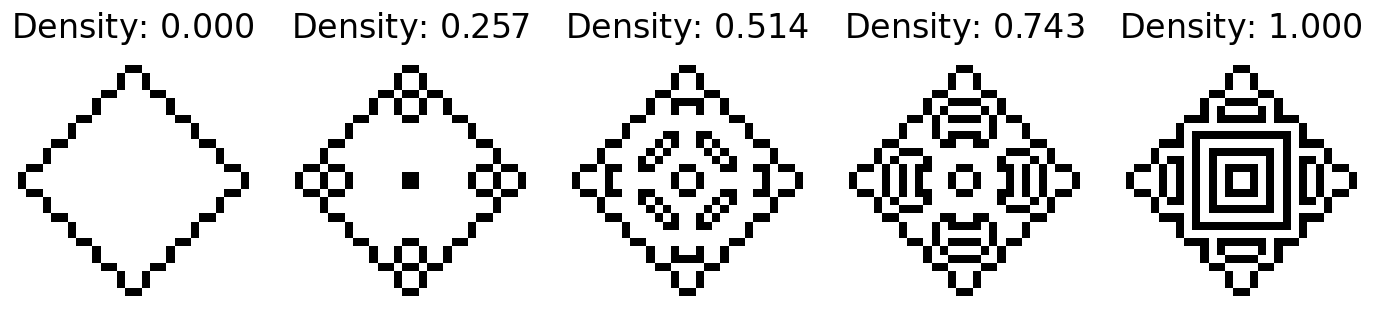

In [2]:
# Load pre-computed patterns
level=5
library = TileLibrary.load(level=level)

print(f"Level {level} patterns: {len(library.tiles)} patterns")
print(f"Pattern size: {library.tiles.shape[1:]}")
print(f"Density range: {library.densities.min():.3f} to {library.densities.max():.3f}")

# Show patterns at different densities
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
fontsize = 24
densities_to_show = [0.0, 0.25, 0.5, 0.75, 1.0]

for ax, target_density in zip(axes, densities_to_show):
    # Find pattern closest to target density
    idx = np.argmin(np.abs(library.densities - target_density))
    pattern = library.tiles[idx]
    actual_density = library.densities[idx]
    
    ax.imshow(pattern, cmap='binary', interpolation='nearest')
    ax.set_title(fr'Density: ${{{actual_density:.3f}}}$', fontsize=fontsize, y=1.05)
    ax.axis('off')

# plt.suptitle(f'Tile patterns for level {level} at different densities', fontsize=fontsize+2, y=1.05)
plt.tight_layout()

plt.savefig(f'gol_mosaics_level_{level}_patterns.pdf', bbox_inches='tight')

plt.show()

Note that these are five different tiles that are all 8-fold symmetric and static according to the rule of the Game of Life. Additionally, they all have different densities. The tile with the lowest number of living cells, on the left, is said to have density 0. The tile with the highest number of living cells, on the right, is said to have density 1.

## Step 2: Elementary - the Pond pattern

The atomic unit of our Still Lifes is a simple pattern consisting of 8 living cells, which in the Game of Life literature known as the Pond pattern. Pond patterns can be tied together to create larger patterns that remain static.

Concretely, we can:
1. Use the Pond pattern as-is: dimensions 6×6 (including the border of dead cells), level 1
2. Tile multiple ponds together into a diamond shape: dimensions (6x6)*level
3. Extract just the edge/border

The border defines the outline of our Tile, and this empty Tile can be filled in numerous ways.

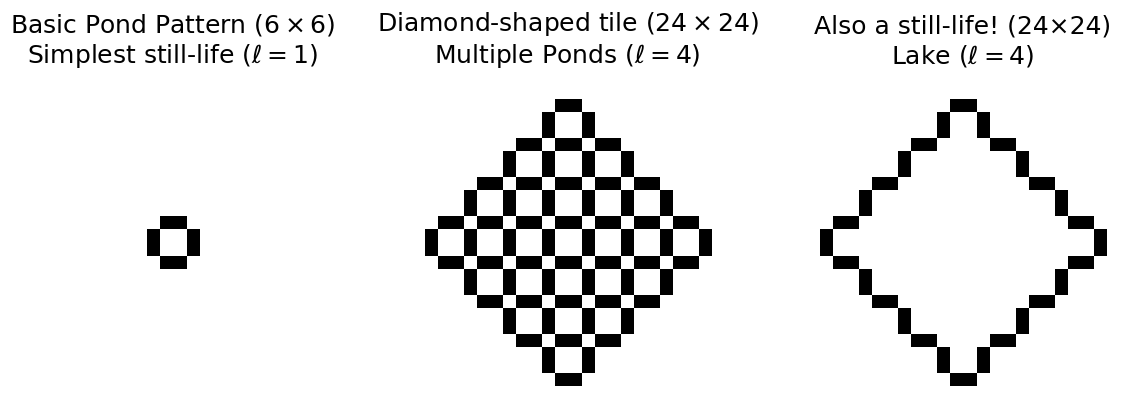

In [3]:
# Show how the pattens are built up
# Use the library from Step 1, or create an instance for pond patterns
level = 4
library = TileLibrary.load(level=level)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fontsize=18
title_offset = 1.05

# 0. get pond_multiple object for dimensions
pond_multiple = pond_lattice(level)
height, width = pond_multiple.shape

# 1. Basic pond pattern (6x6)
basic_pond = POND
basic_pond_show = np.zeros_like(pond_multiple)
basic_pond_show[3*level-2:3*level+2,3*level-2:3*level+2] = basic_pond
axes[0].imshow(basic_pond_show, cmap='binary', interpolation='nearest')
axes[0].set_title(f'Basic Pond Pattern ($6 \\times 6$)\nSimplest still-life ($\\ell = 1$)', fontsize=fontsize, y=title_offset)
axes[0].axis('off')
axes[0].set_xticks(np.arange(-0.5, 4, 1), minor=True)
axes[0].set_yticks(np.arange(-0.5, 4, 1), minor=True)
axes[0].grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# 2. Multiple ponds glued together
axes[1].imshow(pond_multiple, cmap='binary', interpolation='nearest')
axes[1].set_title(f'Diamond-shaped tile (${height}\\times{width}$)\nMultiple Ponds ($\\ell = {level}$)', fontsize=fontsize, y=title_offset)
axes[1].axis('off')

# 3. Edge pattern only
pond_edge = pond_frame(level)
axes[2].imshow(pond_edge, cmap='binary', interpolation='nearest')
axes[2].set_title(f'Also a still-life! ({height}×{width})\nLake ($\\ell = {level}$)', fontsize=fontsize, y=title_offset)
axes[2].axis('off')

# plt.suptitle('Pond Pattern Evolution', fontsize=14, y=1.02)
plt.tight_layout()

plt.savefig(f'gol_mosaics_level_{level}_pond_and_lake.pdf', bbox_inches='tight')

plt.show()

## Step 3: 8-Fold Symmetry

To create mosaics with a diamond/diagonal layout, we need patterns with 8-fold symmetry:
- 4 rotational symmetries (90°, 180°, 270°, 360°)
- 4 reflection symmetries (horizontal, vertical, 2 diagonals)

This means we only need to solve for 1/8 of the pattern - the rest is determined by symmetry!

_Note_: in group theory, this is called the dihedral group $D_4$.

Let's visualise this:

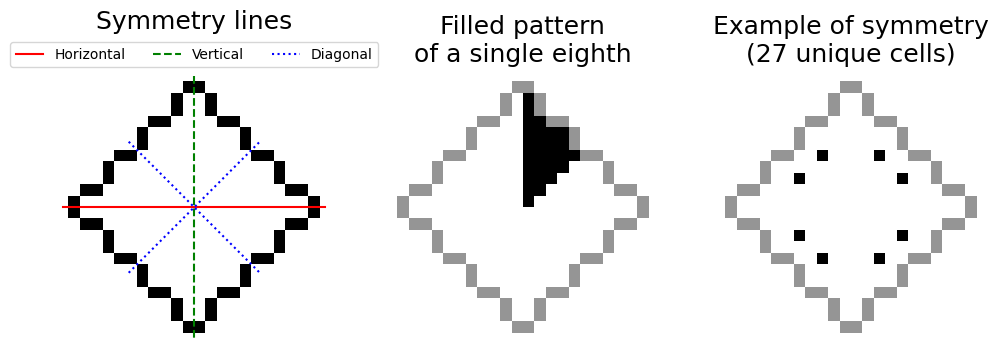

In [4]:
# TODO: this visualisation only works for level 4

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
fontsize = 18

axs[0].imshow(pond_edge, cmap='Greys')

### first figure: symmetry lines
axs[0].plot([0, height-1], [.5*(height-1), .5*(height-1)], color='red', label='Horizontal', ls='-')
axs[0].plot([.5*(height-1), .5*(height-1)], [0, height-1], color='green', label='Vertical', ls='--')
axs[0].plot([.25*(height-1), .75*(height-1)], [.25*(height-1), .75*(height-1)], color='blue', label='Diagonal', ls=':')
axs[0].plot([.25*(height-1), .75*(height-1)], [.75*(height-1), .25*(height-1)], color='blue', ls=':')

axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3)

### second figure: filled pattern of a single eigth
pond_edge_eighth = free_octant(level)
number_unique_cells = np.sum(pond_edge_eighth)
eighth_show = pond_edge + 2*pond_edge_eighth

axs[1].imshow(eighth_show, cmap='Greys')

### third figure: example of symmetry
pond_edge_single = pond_edge.copy()
# test value
(i,j) = height//3+1, height//3-1
pond_edge_single[i,j] = 2

# add all symmetries
pond_edge_single[width-i-1, j] = 2  # vertical symmetry
pond_edge_single[i, width-j-1] = 2  # horizontal symmetry
pond_edge_single[width-i-1, width-j-1] = 2  # vertical and horizontal symmetry
pond_edge_single[j, i] = 2  # diagonal symmetry
pond_edge_single[j, width-1-i] = 2 # diagonal and vertical symmetry
pond_edge_single[width-1-j, i] = 2  # diagonal and horizontal symmetry
pond_edge_single[width-1-j, width-1-i] = 2  # all symmetries

axs[2].imshow(pond_edge_single, cmap='Greys')

axs[0].set_title('Symmetry lines\n', fontsize=fontsize, y=1.02)
axs[1].set_title('Filled pattern\nof a single eighth', fontsize=fontsize)
axs[2].set_title(f'Example of symmetry\n({number_unique_cells} unique cells)', fontsize=fontsize)

for ax in axs:
    ax.axis('off')

# plt.savefig(f'gol_mosaics_level_{level}_symmetry_explanation.pdf', bbox_inches='tight')

## Step 4: Comparing tile levels

Different levels produce patterns of different sizes and more pattern possibilities:

- **Level 1**: 6x6 tiles (1 tile)
- **Level 2**: 12x12 tiles (2 patterns)
- **Level 3**: 18×18 tiles (7 patterns)
- **Level 4**: 24×24 tiles (85 patterns)  
- **Level 5**: 30×30 tiles (2632 patterns)

Notice how higher levels can achieve
- More intricate details
- Better density precision
- More varied structures

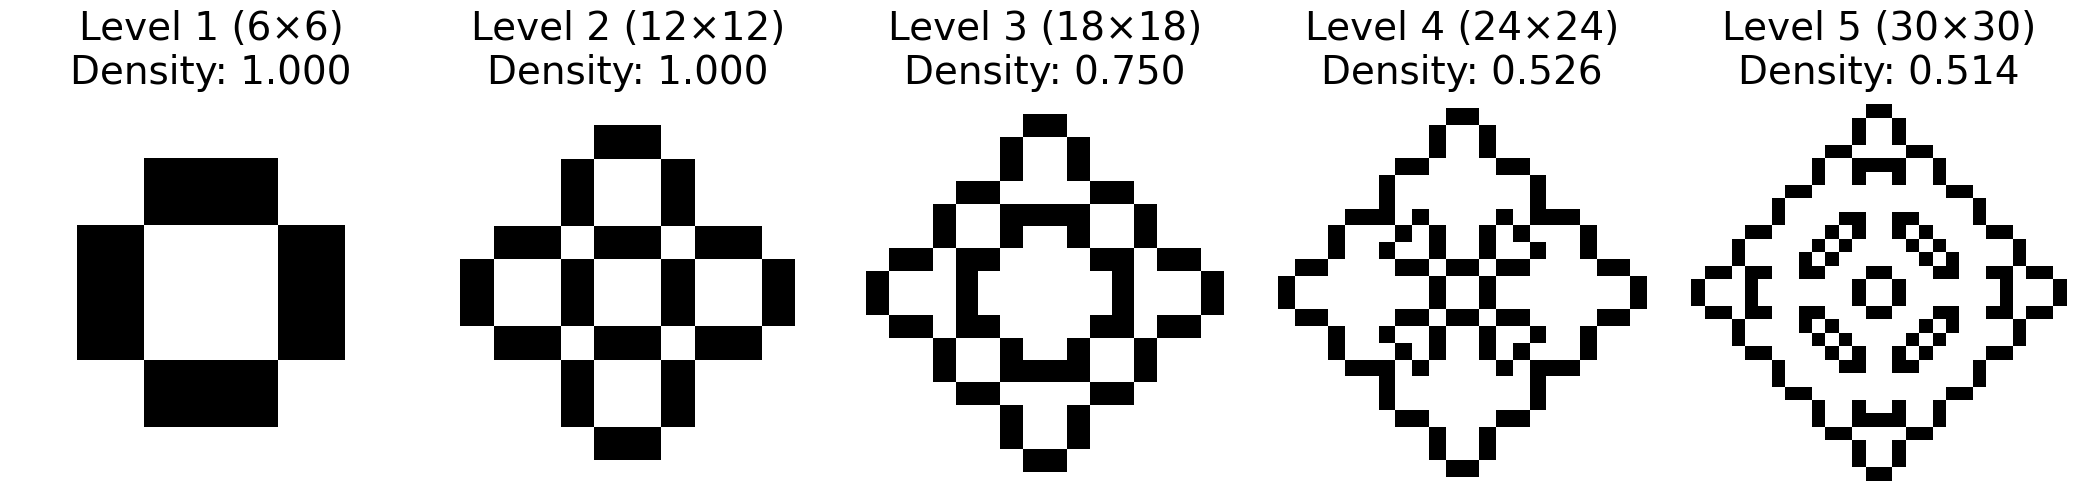

In [5]:
# Compare different levels
fig, axes = plt.subplots(1, 5, figsize=(21, 5))
fontsize=28

levels = [1, 2, 3, 4, 5]
target_density = 0.5

for ax, level in zip(axes, levels):
    library = TileLibrary.load(level=level)
    
    # Find pattern closest to target density
    idx = np.argmin(np.abs(library.densities - target_density))
    pattern = library.tiles[idx]
    actual_density = library.densities[idx]
    
    size = 6*level
    ax.imshow(pattern, cmap='binary', interpolation='nearest')
    ax.set_title(f'Level {level} ({size}×{size})\nDensity: {actual_density:.3f}', fontsize=fontsize)
    ax.axis('off')

# plt.suptitle('Pattern Complexity at Different Levels', fontsize=fontsize+2, y=1.03)
plt.tight_layout()

plt.savefig('gol_mosaics_pattern_complexity_comparison.pdf', bbox_inches='tight')

plt.show()

These tiles are the building blocks of the mosaics we will be creating.